In [246]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import airy

In [247]:
#CONSTANTS
c = 299792458.0
e = 1.60217663e-19
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895 

In [248]:
#ENERGY PARAMETERS
E_MeV = 100  #Note: Code is compatible with energy parameters in only within MeV range
E_total = E_MeV + m_e_MeV
gamma = E_total / m_e_MeV
beta = np.sqrt(1 - 1 / gamma**2)
v = beta * c

In [249]:
#CHARGE PARAMETERS
bunchcharge = 5e-12
Ne = bunchcharge/e

In [250]:
#BEAM PARAMETERS - OAM + GAUSSIAN (in m)
sigma_x = sigma_y = 100-6

In [251]:
#TEMPORAL PULSE (in sec)
sigma_t = 1e-12

In [252]:
#SIGMA Z
sigma_z = c * sigma_t

In [253]:
#OBSERVATION GRIDS
Nangle, Nlam = 1000, 1000
th = np.linspace(-0.2, 0.2, Nangle)
lam = np.linspace(1e-6,1e-5, Nlam)
TH, LAM = np.meshgrid(th, lam, indexing='ij')
phi = np.linspace(0, 2*np.pi, Nangle, endpoint=False)
omega = 2*np.pi*c/lam

In [254]:
#SINGLE ELECTRON SPECTRUM
A = e**2 / (4*np.pi * eps0 * c)
W1 = A*(beta**2 * np.sin(TH)**2) / (1.0 - beta**2 * np.cos(TH)**2)**2

In [255]:
#SPATIAL ELECTRON DIST GRIDS
x = np.linspace(-sigma_x, sigma_x, 1000)
y = np.linspace(-sigma_y, sigma_y, 1000)
z = np.linspace(-8*sigma_z, 8*sigma_z, 1000) 

In [256]:
#BUILDING GAUSSIAN DIST
def rho_gaussian_3d(x, y, z, sigma_x, sigma_z):
    r2 = x**2 + y**2
    return np.exp((-(r2) / (2*sigma_x**2)) - (z**2 / (2*sigma_z**2)))

rho_g = rho_gaussian_3d(x, y, z, sigma_x, sigma_z)

In [257]:
#BUILDING OAM DIST
def rho_oam_3d(x, y, z, sigma_x, sigma_z, l):
    r2 = x**2 + y**2
    return (r2**l) * np.exp((-(r2) / (2*sigma_x**2)) - (z**2 / (2*sigma_z**2)))

rho_o = rho_oam_3d(x, y, z, sigma_x, sigma_z, l=2)

In [258]:
#BUILDING AIRY DIST
#Note: Airy distribution is contstructed slightly differently than that of Gaussian or OAM. x is the transverse dimension of the beam, while z is the prop distance of the Airy beam.
x_airy = np.linspace(-8*sigma_x, 8*sigma_x, 1000) #
z_airy = np.linspace(0.0, 0.0001, 1000)
def airy_beam_scaled(x, z, wavelength, x0, a=0.05):
    k = 2*np.pi/wavelength
    X, Z = np.meshgrid(x, z, indexing='ij')
    s= X/x0
    xi=z/(k*x0**2)
    arg = s - (xi**2)/4 + 1j*a*xi
    Ai, _, _, _ = airy(arg)
    phase = (s*xi)/2 - (xi**3)/12 + (xi*a**2)/2
    amp = a*(s - (xi**2)/2)
    psi = Ai * np.exp(amp + 1j*phase)
    return psi, xi

psi, xi = airy_beam_scaled(x_airy, z_airy, lam, sigma_x, a=0.05)
psi = np.abs(psi[0])**2

In [259]:
#FORM FACTOR
#Note: For simplicity, we only consider and visualize one dimension
def f2(omega, theta, rho_z, z, beta):
    dz = z[1] - z[0]
    rho = rho_z / np.trapz(rho_z, z)
    Rk = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho))) * dz
    kz = np.fft.fftshift(2*np.pi*np.fft.fftfreq(z.size, d=dz))
    Rk /= Rk[np.argmin(np.abs(kz))]
    k = omega / c
    kz_target = k[None, :] * (1.0/beta - np.cos(theta)[:, None])
    kz_flat = np.clip(kz_target.ravel(), kz[0], kz[-1])
    f2 = np.interp(kz_flat, kz, np.abs(Rk)**2).reshape(kz_target.shape)
    return f2

In [260]:
#CALCULATING BUNCH SPECTRUM
def electron_bunch_spectrum(W1, Ne, omega, th, rho_z, z, beta):
    Wn_list = []
    F2 = f2(omega, th, rho_z, z, beta)
    Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))
    stack = np.stack(Wn_list, axis=0)
    positive = stack[stack > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = stack.max()
    return Wn_list, vmin, vmax, F2

In [261]:
Wn_list_g, vmin_g, vmax_g, F2_g = electron_bunch_spectrum(W1, Ne, omega, th, rho_g, z, beta)
Wn_list_o, vmin_o, vmax_o, F2_o = electron_bunch_spectrum(W1, Ne, omega, th, rho_o, z, beta)
Wn_list_a, vmin_a, vmax_a, F2_a = electron_bunch_spectrum(W1, Ne, omega, th, psi, z, beta)

In [262]:
#PLOTTING
def plot_ctr_spectrum(th, lam, Wn_list, vmin, vmax, title = 'CTR'):
    fig, ax = plt.subplots()  
    im = ax.pcolormesh(th, lam, np.maximum(Wn_list[0].T, vmin), shading='auto', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax)) #vmin and vmax are contingent on the form factor therefore for the ease of comparsion this could be set to vmin=10e-25, vmax=10e-18
    ax.set_title(title)
    ax.set_xlabel(r'$\theta$ (rad)')
    ax.set_ylabel(r'$\lambda$ (m)')
    ax.set_ylim(lam.min(), lam.max())
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'$W_n$ (LogNorm)')

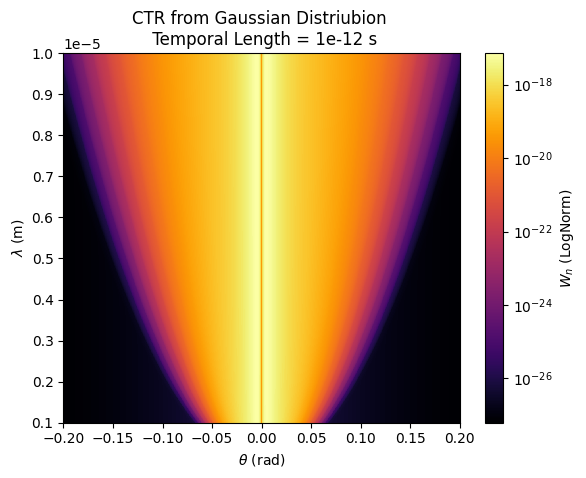

In [263]:
plot_ctr_spectrum(th, lam, Wn_list_g, vmin_g, vmax_g, title = f'CTR from Gaussian Distriubion \n Temporal Length = {sigma_t} s')

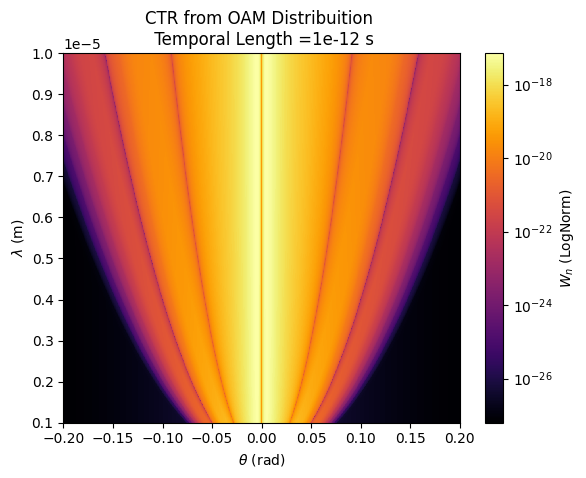

In [264]:
plot_ctr_spectrum(th, lam, Wn_list_o, vmin_o, vmax_o, title = f'CTR from OAM Distribuition \n Temporal Length ={sigma_t} s')

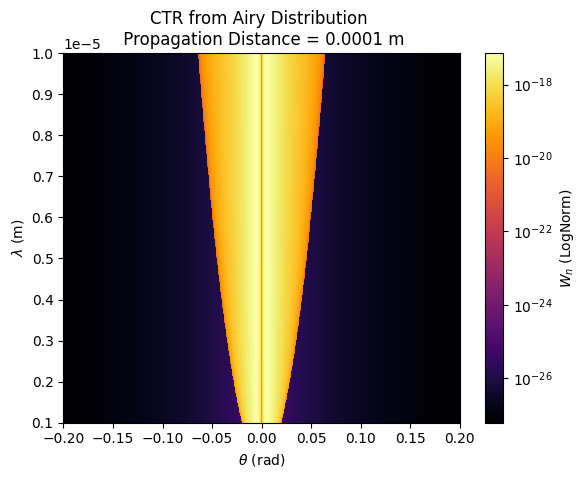

In [265]:
plot_ctr_spectrum(th, lam, Wn_list_a, vmin_a, vmax_a, title=f'CTR from Airy Distribution \n Propagation Distance = {z_airy[-1]} m')

In [266]:
#INTEGRATION OF WN WITH RESPECT TO BIG OMEGA
def integrate_Wn_over_Omega(Wn_list, th, TH, lam, title='Photon Count', logscale=True):
    jac = 2 * np.pi * np.sin(TH)
    Wn_int = [np.trapz(np.abs(Wn * jac), th, axis=0) for Wn in Wn_list]
    Wn_int_array = np.array(Wn_int)
    plt.figure()
    for i, spectrum in enumerate(Wn_int_array):
        plt.plot(lam, spectrum)
    if logscale:
        plt.yscale('log')
    plt.xlabel(r'$\lambda$ [m]')
    plt.ylabel('Photon Count (Scaled)')
    plt.title(title)

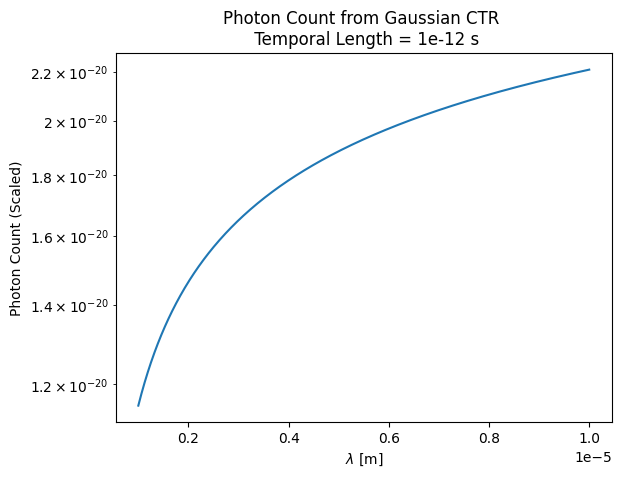

In [267]:
integrate_Wn_over_Omega(Wn_list_g, th, TH, lam, title=f'Photon Count from Gaussian CTR \n Temporal Length = {sigma_t} s')

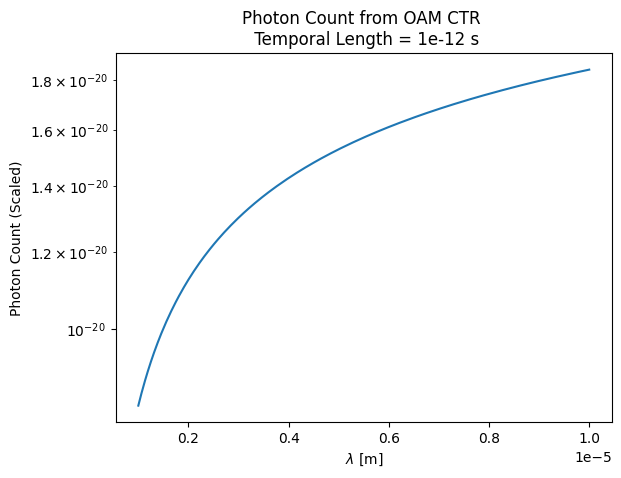

In [268]:
integrate_Wn_over_Omega(Wn_list_o, th, TH, lam, title=f'Photon Count from OAM CTR \n Temporal Length = {sigma_t} s')

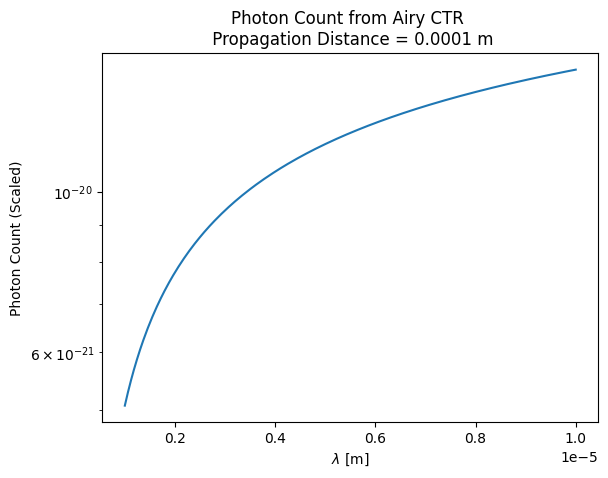

In [270]:
integrate_Wn_over_Omega(Wn_list_a, th, TH, lam, title=f'Photon Count from Airy CTR \n Propagation Distance = {z_airy[-1]} m')